<a href="https://colab.research.google.com/github/a01038007367-pixel/-/blob/main/05.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving 스도쿠256.raw to 스도쿠256 (36).raw


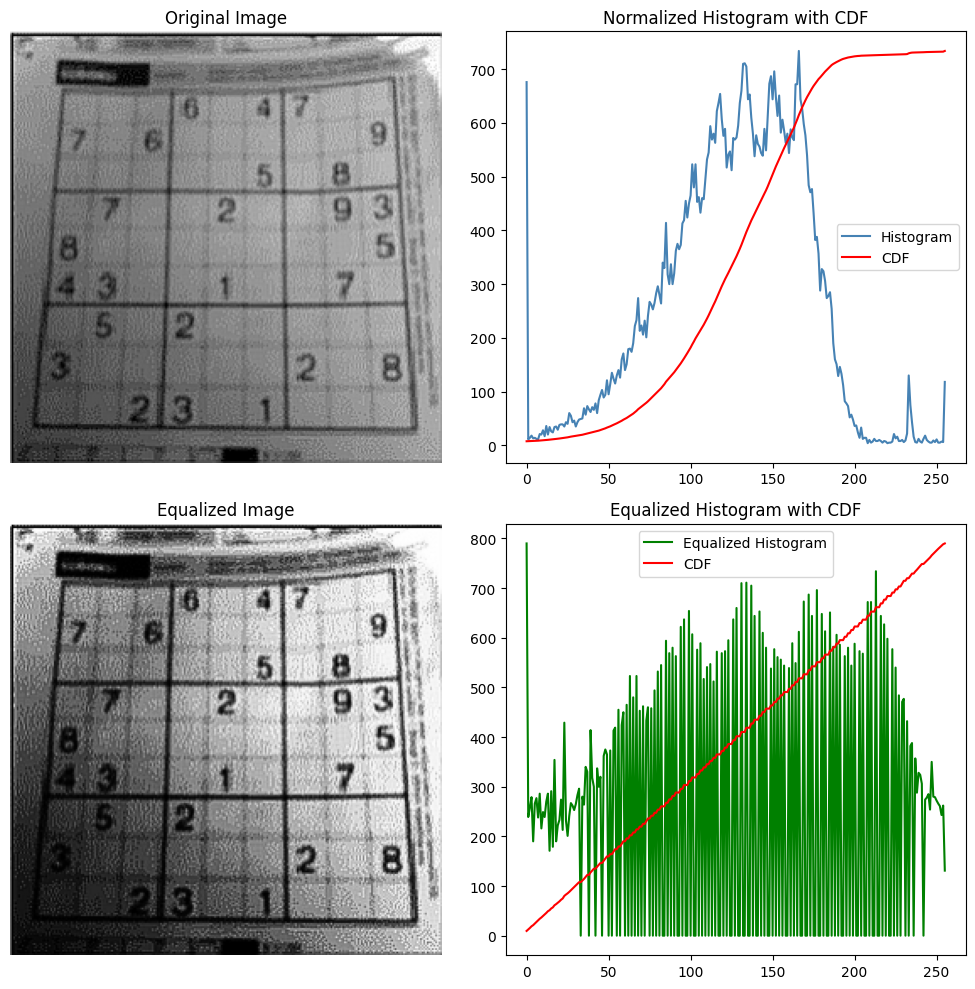

In [40]:
from google.colab import files
import numpy as np
import cv2
import matplotlib.pyplot as plt

# 1. 이미지 불러오기
uploaded = files.upload()
filename = list(uploaded.keys())[0]

# 1.1 RAW 이미지 읽기 (예: 256x256)
img = np.fromfile(filename, dtype=np.uint8)
img = img.reshape((256, 256))

# 정규화 히스토그램
hist_norm = hist / hist.sum()   #픽셀 개수

# 누적 히스토그램
cum_hist = hist_norm.cumsum()   #누적 합계

# 정규화 히스토그램의 누적 합계->CDF(누적 분포 함수)
hist, bins = np.histogram(img.flatten(), bins=256, range=[0,256])
cdf = hist.cumsum()            # 정규화 배열 누적 합계

# 평활화 히스토그램
hist_eq, bins_eq = np.histogram(img_eq.flatten(), bins=256, range=[0,256])
cdf_eq = hist_eq.cumsum()       # 평활화 배열 누적 합계

# 평활화된 이미지 및 히스토그램
img_eq = cv2.equalizeHist(img)

#시각화
plt.figure(figsize=(10, 10))

# 원본 이미지
plt.subplot(2,2,1)
plt.imshow(img, cmap='gray')
plt.title('Original Image')
plt.axis('off')  #이미지 자체 표시

#정규화 히스토그램 CDF
plt.subplot(2,2,2)
cdf_normalized = cdf * float(hist.max()) / cdf.max()   #스케일 조정,CDF의 최대값=히스토그램의 최대값
plt.plot(hist, color='steelblue', label='Histogram')
plt.plot(cdf_normalized, color='red', label='CDF')
plt.title('Normalized Histogram with CDF')
plt.legend() #범례

# 평활화된 이미지
plt.subplot(2,2,3)
plt.imshow(img_eq, cmap='gray')
plt.title('Equalized Image')
plt.axis('off')  #이미지 자체 표시

#평활화 히스토그램 CDF
plt.subplot(2,2,4)
cdf_eq_normalized = cdf_eq * float(hist_eq.max()) / cdf_eq.max()  #스케일 조정,CDF의 최대값=히스토그램의 최대값
plt.plot(hist_eq, color='green', label='Equalized Histogram')
plt.plot(cdf_eq_normalized, color='red', label='CDF')
plt.title('Equalized Histogram with CDF')
plt.legend() #범례

plt.tight_layout()
plt.show()

